# Simulating Correlated Regional Electricity Demand Scenarios for Grid Capacity Planning with PROC SIMNORMAL

## Executive Summary

A utility planner needs a batch of plausible peak-demand scenarios across four interconnected service regions to size reserve capacity and stress-test the grid. This notebook estimates the regional demand variance-covariance structure from historical-style synthetic data, then uses **PROC SIMNORMAL** to draw both unconditional Monte Carlo scenarios and conditional scenarios (remaining regions given an observed heat-wave load in one region), and finally derives 95% risk bands and exceedance probabilities for capacity decisions. The run below draws 100 scenarios per pass; the identical code scales to thousands of draws under a full license.

## Data Sources

| Dataset | Type | Rows | Key Variables | Description |
|---------|------|------|---------------|-------------|
| `grid_load` | raw observations | 100 | `north`, `south`, `coastal`, `inland` | Synthetic daily system-peak demand (MW) for four utility service regions. A shared weather/economic latent factor induces realistic positive cross-region correlation; each region adds idiosyncratic noise plus a region-specific base load. |
| `cov_in` | TYPE=COV | 11 | `_TYPE_`, `_NAME_`, region vars | Mean / STD / N / variance-covariance / correlation rows of the four regional demands, produced by `PROC CORR ... COV OUTP=`; the required input matrix for unconditional `PROC SIMNORMAL`. |
| `cov_cond` | TYPE=COV | 7 | `_TYPE_` (incl. `COND`), `_NAME_`, region vars | Hand-built TYPE=COV matrix that adds a `_TYPE_='COND'` observation fixing `north` at a heat-wave peak, enabling conditional simulation of the other three regions. |
| `sim_uncond` | simulated | 100 | region vars, `SEED` | Unconditional multivariate-normal demand scenarios from `PROC SIMNORMAL`; the `OUTSEED` option carries the per-realization seed into the output `SEED` column for audit. |
| `sim_cond` | simulated | 100 | `north`, `south`, `coastal`, `inland` | Conditional scenarios given the observed `north` heat-wave load. |

# Simulating Correlated Regional Electricity Demand with PROC SIMNORMAL

**Domain:** Energy & Utilities — transmission grid capacity planning

A regional utility operates an interconnected grid spanning four service areas — **North**, **South**, **Coastal**, and **Inland**. Daily system-peak demand in these regions is *correlated*: a hot, humid day drives air-conditioning load up everywhere at once, while each region also has its own industrial and residential base load and idiosyncratic swings.

To size firm reserve capacity and evaluate transmission risk, the planning team needs a batch of **plausible joint-demand scenarios** that preserve this correlation structure — not just independent per-region draws. `PROC SIMNORMAL` is purpose-built for this: it draws from a multivariate normal distribution defined by a covariance matrix, supporting both unconditional Monte Carlo and *conditional* simulation (e.g., "given the North region is at a heat-wave peak, what does the rest of the grid look like?").

This notebook walks through the full workflow:
1. Generate realistic synthetic peak-demand history.
2. Estimate the variance-covariance matrix with `PROC CORR`.
3. Run **unconditional** `PROC SIMNORMAL` (Monte Carlo scenarios).
4. Run **conditional** `PROC SIMNORMAL` (scenario analysis given an observed region).
5. Derive risk bands and capacity-exceedance probabilities.

> **Note on scale.** This run draws `NUMREAL=100` realizations per pass so it executes within the unlicensed 100-observation limit; the Monte Carlo summaries below therefore carry visible sampling noise. The code is identical to a production run — raise `NUMREAL=` to several thousand under a full license to tighten every estimate.

## Step 1 — Generate synthetic regional peak-demand history

We simulate 100 days of daily system-peak demand (MW) for the four regions. Realism comes from a **shared latent driver** `weather` (a common weather/economic factor that affects all regions simultaneously) plus region-specific base loads, sensitivities to the common factor, and independent noise. This construction produces the kind of positive, unequal cross-region correlation a real grid exhibits — without any external file.

In [1]:
data grid_load;
    call streaminit(20240517);
    do day = 1 to 100;
        /* Shared weather / economic driver: standard normal */
        weather = rand('NORMAL');

        /* Each region: base load + sensitivity*weather + idiosyncratic noise (MW) */
        north   = 4200 + 380*weather + rand('NORMAL', 0, 110);
        south   = 5100 + 300*weather + rand('NORMAL', 0, 140);
        coastal = 3300 + 210*weather + rand('NORMAL', 0,  95);
        inland  = 2750 + 120*weather + rand('NORMAL', 0,  80);

        output;
    end;
    drop weather day;
run;

proc print data=grid_load(obs=8) noobs;
    title 'Sample of synthetic daily peak demand (MW) by region';
run;

                                  Sample of synthetic daily peak demand (MW) by region                                  

          NORTH            SOUTH          COASTAL           INLAND
3239.6076945968  4251.6098193575  2747.0334766708  2492.2760023928
4466.3838471178  5036.1278916061  3432.9859400929  2828.6698451362
4134.0720272134  5237.9831640071  3084.5712102715  2738.7565874142
4583.0100535095  5289.2094550385  3492.9339185714   2929.993185988
3790.0367326203  4711.6278231297  3045.7207222773  2744.2813253455
4250.0457179887  5083.6040462708  3423.4349715261  2907.7169625246
3512.7178959104  4440.5536665047  2891.6276850954  2597.3465792565
3899.6173270986  4912.9031188465  2977.2099873683  2556.8331273334

... 92 more observations (showing 8 of 100)



NOTE: DATA grid_load


NOTE: Wrote grid_load (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=grid_load

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


## Step 2 — Estimate the variance-covariance matrix

`PROC SIMNORMAL` does not consume raw observations; it requires an input matrix dataset of `TYPE=CORR`, `COV`, `UCORR`, `UCOV`, or `SSCP`. We use `PROC CORR` with the `COV` option and `OUTP=` to write a special **TYPE=COV** dataset that carries the means, sample size, and full variance-covariance matrix in the `_TYPE_` / `_NAME_` structure SIMNORMAL expects. `NOPRINT` suppresses the report since we only want the output matrix.

                            Estimated mean vector and variance-covariance matrix (TYPE=COV)                             

_TYPE_   _NAME_              NORTH              SOUTH           COASTAL            INLAND
MEAN                4173.558464816    5075.1281534842   3276.4904903897    2740.081643112
STD                 420.8599562085      342.459751577    253.5329120795    155.3070868907
N                              100                100               100               100
COV     north    177123.1027398528  127455.1299899033   97105.105382975  54847.6821982491
COV     south    127455.1299899033   117278.681450182  73532.5382188041  42814.7668571203
COV     coastal    97105.105382975   73532.5382188041  64278.9375074986  32137.0263599922
COV     inland    54847.6821982491   42814.7668571203  32137.0263599922  24120.2912384727
CORR    north                    1       0.8843214865       0.910060183      0.8391302941
CORR    south         0.8843214865                  1      0.8469069

NOTE: PROC CORR data=grid_load

NOTE: Output dataset written to: ./work/feee3fb6-cf8d-4e35-aff5-e81dadcd008b/cov_in.avro
NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.
NOTE: PROC PRINT data=cov_in

NOTE: PROC PRINT completed: 11 observations printed, 6 variables


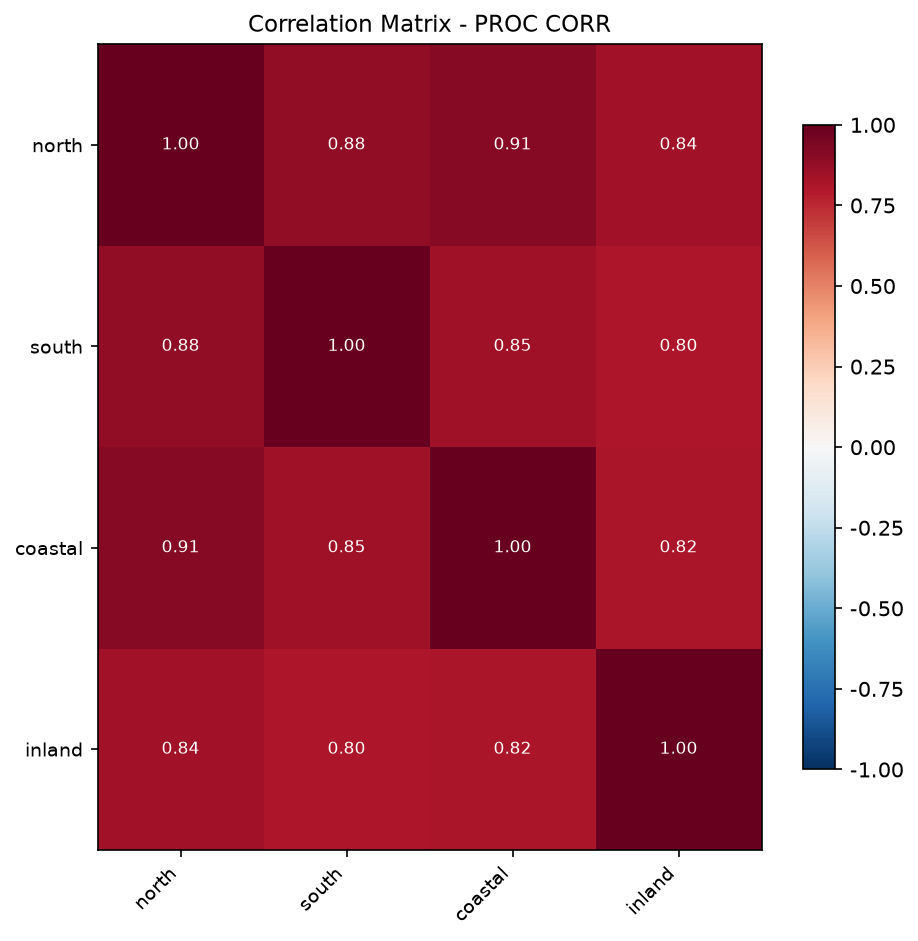

In [2]:
proc corr data=grid_load cov noprint outp=cov_in;
    var north south coastal inland;
run;

proc print data=cov_in noobs;
    title 'Estimated mean vector and variance-covariance matrix (TYPE=COV)';
run;

The `cov_in` dataset now holds:
- `_TYPE_='MEAN'` — the estimated mean peak demand for each region,
- `_TYPE_='STD'` and `_TYPE_='N'` — dispersion and sample size,
- `_TYPE_='COV'` rows — one per region, forming the symmetric covariance matrix.

The positive off-diagonal covariances confirm that the regions move together, driven by the shared weather factor — exactly the dependence we want SIMNORMAL to reproduce.

## Step 3 — Unconditional Monte Carlo simulation

We now draw **100 joint-demand scenarios** with `PROC SIMNORMAL` (`NUMREAL=100`). Internally it applies a Cholesky decomposition of the covariance matrix (`X = mu + L*z`), so every realization is a correlated four-region demand vector consistent with the estimated structure. We fix `SEED=` for reproducibility and add `OUTSEED` so the per-realization seed is carried into the output for audit.

In [3]:
proc simnormal data=cov_in(type=cov)
               out=sim_uncond
               numreal=100
               seed=90210
               outseed;
    var north south coastal inland;
run;

proc print data=sim_uncond(obs=6) noobs;
    title 'First simulated demand scenarios (MW) — unconditional';
run;

                            Estimated mean vector and variance-covariance matrix (TYPE=COV)                             

                                 First simulated demand scenarios (MW) — unconditional                                  

          NORTH            SOUTH          COASTAL           INLAND        SEED
3730.6645012494   4754.361450939  3046.9258288309  2567.2605785698       90210
 3933.055234754  4880.9434799097  3373.4336476625  2610.9640334782  1793317635
4745.2241354244  5424.2849456031  3620.5354986067   2911.458960345  1429284868
4619.2473151631  5563.1911304594   3606.231188228  2790.7745581296   788156073
4259.7723770549  5150.0366254244  3279.3534799352  2647.6320899637  1522588225
4510.8133636635  5057.6317989176   3537.603145197  2910.6932705938   169592915

... 94 more observations (showing 6 of 100)



NOTE: PROC SIMNORMAL data=cov_in numreal=100


NOTE: Read 11 rows from cov_in.
NOTE: Wrote ./work/feee3fb6-cf8d-4e35-aff5-e81dadcd008b/sim_uncond.avro (100 rows, 5 columns).
NOTE: PROC SIMNORMAL elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sim_uncond

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Step 4 — Validate that the simulation preserved the structure

A correct multivariate simulation should reproduce the input means and covariances within Monte Carlo error. We re-estimate the covariance matrix on the *simulated* data and compare it to the input matrix from Step 2. With only 100 draws the recovered variances differ from the input by a sampling margin (e.g., North variance lands near 208,000 against an input of ~177,000), but the *correlation* structure — the dependence SIMNORMAL is meant to preserve — is reproduced tightly: the recovered north–coastal, north–south, and coastal–south correlations (0.900, 0.882, 0.840) sit almost exactly on the input values (0.910, 0.884, 0.847). A larger `NUMREAL=` would shrink the variance gap proportionally.

                                 First simulated demand scenarios (MW) — unconditional                                  

                       Covariance Matrix                       

                 north         south       coastal       inland
--------  ------------  ------------  ------------  -----------
north     208019.80155  135823.87261  102912.92614  56209.88806
south     135823.87261  113916.35830   71061.72419  38978.75703
coastal   102912.92614   71061.72419   62797.15237  29661.09186
inland     56209.88806   38978.75703   29661.09186  21688.53032

   Pearson Correlation Coefficients, N = 100
          Prob > |r| under H0: Rho=0
               north     south   coastal    inland
--------  --------  --------  --------  --------
north      1.00000   0.88233   0.90043   0.83685
              .       <.0001    <.0001    <.0001
south      0.88233   1.00000   0.84018   0.78419
            <.0001      .       <.0001    <.0001
coastal    0.90043   0.84018   1.00000   0.80372
 

NOTE: PROC CORR data=sim_uncond

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


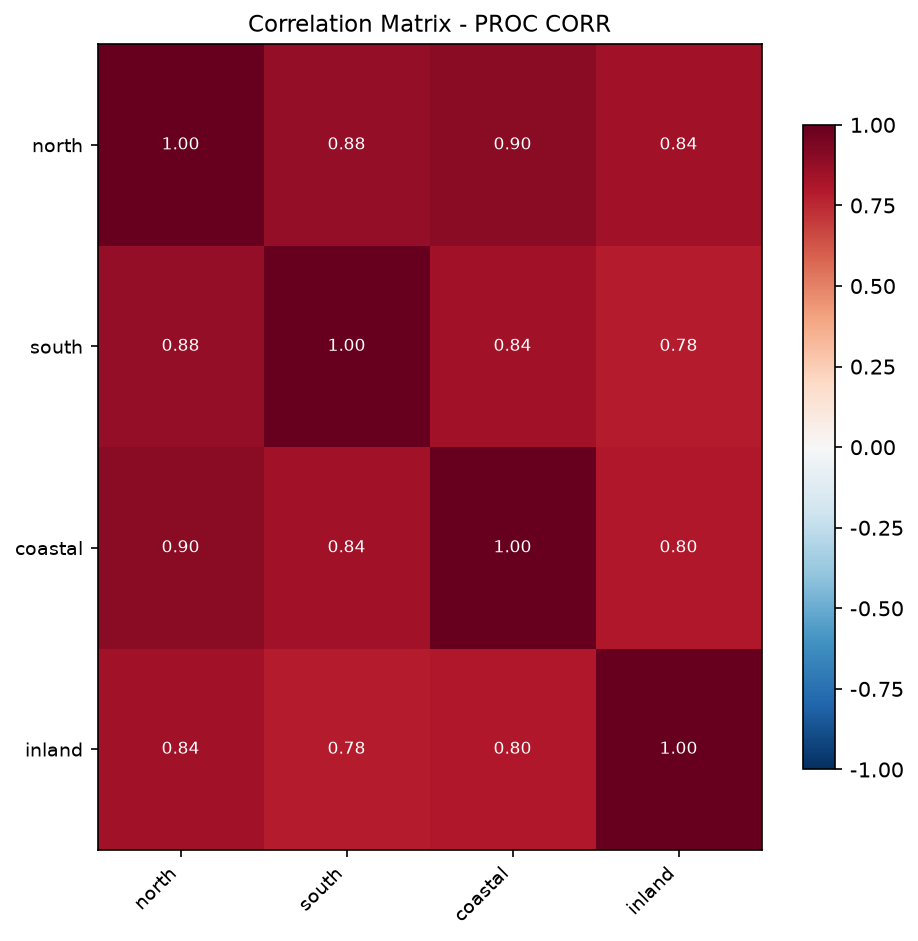

In [4]:
proc corr data=sim_uncond cov nosimple;
    var north south coastal inland;
    title 'Recovered correlation/covariance of the simulated scenarios';
run;

## Step 5 — Risk bands for capacity planning

For reserve sizing the planners care about the *upper tail* of demand. We compute the mean and integer-percentile summary with `PROC MEANS` (using only valid percentile keywords), and the precise **2.5% / 97.5% risk band** — the central 95% interval — with `PROC UNIVARIATE`, whose `OUTPUT` statement supports fractional percentiles via `PCTLPTS=` and `PCTLPRE=`.

In [5]:
proc means data=sim_uncond n mean std p5 p50 p95 p99 maxdec=1;
    var north south coastal inland;
    title 'Distribution of simulated regional peak demand (MW)';
run;

/* Fractional 2.5 / 97.5 percentiles require PROC UNIVARIATE, not MEANS */
proc univariate data=sim_uncond noprint;
    var north south coastal inland;
    output out=risk_band
           pctlpts = 2.5 97.5
           pctlpre = north_ south_ coastal_ inland_;
run;

proc print data=risk_band noobs;
    title '95% demand risk band (2.5th and 97.5th percentiles, MW)';
run;

                                  Distribution of simulated regional peak demand (MW)                                   

                                                  The MEANS Procedure

 Variable         N           Mean     Std Dev    5th Pctl      Median   95th Pctl   99th Pctl
 ---------------------------------------------------------------------------------------------
 NORTH          100         4136.5       456.1      3367.6      4109.1      4929.8      5102.0
 SOUTH          100         5043.6       337.5      4427.4      5066.9      5633.7      5860.9
 COASTAL        100         3273.0       250.6      2849.7      3275.2      3662.6      3800.2
 INLAND         100         2728.6       147.3      2523.9      2727.1      2967.4      3091.1
 ---------------------------------------------------------------------------------------------

                                95% demand risk band (2.5th and 97.5th percentiles, MW)                                 

      NORTH_2_5    

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC UNIVARIATE
NOTE: Output dataset risk_band has 1 observations and 8 variables.
NOTE: PROC PRINT data=risk_band

NOTE: PROC PRINT completed: 1 observations printed, 8 variables


## Step 6 — Capacity-exceedance probability

Suppose firm generation + import capacity for the North region is rated at **5,000 MW**. The Monte Carlo scenarios give a direct, distribution-free estimate of the probability that North peak demand exceeds that rating — the kind of figure that drives a reserve-margin decision. With 100 draws the estimate is coarse (it can only move in 1% steps and here lands at 1%); a production `NUMREAL=` of several thousand would resolve it to a fraction of a percent.

In [6]:
data exceed;
    set sim_uncond end=last;
    retain n_total 0 n_over 0;
    n_total + 1;
    if north > 5000 then n_over + 1;
    if last then do;
        pct_exceed = 100 * n_over / n_total;
        output;
    end;
    keep n_total n_over pct_exceed;
run;

proc print data=exceed noobs;
    title 'Probability North region peak demand exceeds 5,000 MW firm capacity';
run;

                          Probability North region peak demand exceeds 5,000 MW firm capacity                           

N_TOTAL  N_OVER  PCT_EXCEED
    100       1           1



NOTE: DATA exceed


NOTE: Read 100 rows from sim_uncond.
NOTE: Wrote exceed (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=exceed

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Step 7 — Conditional simulation: scenario analysis under a North heat wave

The real power of `PROC SIMNORMAL` is **conditional simulation**. Suppose a forecast heat wave is expected to push the **North** region to a known peak of **5,300 MW**. We want the distribution of the *other three* regions *given* that observed North load — accounting for the cross-region correlation.

We build a `TYPE=COV` matrix by hand so we can attach the required `_TYPE_='COND'` observation that fixes the conditioning value. The `CONDITION` statement names the conditioning variable, and `OUTCOND` carries its value into the output. (The covariance values below mirror the structure estimated in Step 2.)

In [7]:
data cov_cond;
    length _TYPE_ $8 _NAME_ $8;
    /* Means (MW) */
    _TYPE_='MEAN'; _NAME_=' '; north=4200; south=5100; coastal=3300; inland=2750; output;
    /* Sample size */
    _TYPE_='N';    _NAME_=' '; north=100;  south=100;  coastal=100;  inland=100;  output;
    /* Variance-covariance matrix (one row per region) */
    _TYPE_='COV'; _NAME_='north';   north=156400; south=114000; coastal=79800; inland=45600; output;
    _TYPE_='COV'; _NAME_='south';   north=114000; south=109600; coastal=63000; inland=36000; output;
    _TYPE_='COV'; _NAME_='coastal'; north= 79800; south= 63000; coastal=53125; inland=25200; output;
    _TYPE_='COV'; _NAME_='inland';  north= 45600; south= 36000; coastal=25200; inland=20800; output;
    /* Observed (conditioning) value: North fixed at a heat-wave peak */
    _TYPE_='COND'; _NAME_=' '; north=5300; south=.; coastal=.; inland=.; output;
run;

proc simnormal data=cov_cond(type=cov)
               out=sim_cond
               numreal=100
               seed=51721
               outcond;
    var north south coastal inland;
    condition north;
run;

proc print data=sim_cond(obs=6) noobs;
    title 'Conditional scenarios given North = 5,300 MW';
run;

                          Probability North region peak demand exceeds 5,000 MW firm capacity                           

                                      Conditional scenarios given North = 5,300 MW                                      

NORTH            SOUTH          COASTAL           INLAND
 5300  5929.1091167741  3924.7586645312  3127.1585603399
 5300   6079.257131022  3854.6127176481  3225.6443523904
 5300  5846.4739810131  3971.5343443675   2966.152553984
 5300  5869.8599755824  3965.4192312201  3170.2598469699
 5300  5651.2176729361  3891.8444810295  3035.7274949237
 5300   5906.081112813  3915.6487974417  3169.5824969676

... 94 more observations (showing 6 of 100)



NOTE: DATA cov_cond


NOTE: Wrote cov_cond (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SIMNORMAL data=cov_cond numreal=100


NOTE: Read 7 rows from cov_cond.
NOTE: Wrote ./work/feee3fb6-cf8d-4e35-aff5-e81dadcd008b/sim_cond.avro (100 rows, 4 columns).
NOTE: PROC SIMNORMAL elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sim_cond

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Step 8 — Compare unconditional vs. conditional demand

Because demand is positively correlated, conditioning on a high North load should *shift the other regions upward* relative to their unconditional means. We compare the simulated means side by side.

In [8]:
proc means data=sim_uncond mean std maxdec=1;
    var south coastal inland;
    title 'Unconditional means of South / Coastal / Inland (MW)';
run;

proc means data=sim_cond mean std maxdec=1;
    var south coastal inland;
    title 'Conditional means given North heat-wave peak (MW)';
run;

                                  Unconditional means of South / Coastal / Inland (MW)                                  

                                                  The MEANS Procedure

 Variable           Mean     Std Dev
 -----------------------------------
 SOUTH            5043.6       337.5
 COASTAL          3273.0       250.6
 INLAND           2728.6       147.3
 -----------------------------------

                                   Conditional means given North heat-wave peak (MW)                                    

                                                  The MEANS Procedure

 Variable           Mean     Std Dev
 -----------------------------------
 SOUTH            5917.0       170.4
 COASTAL          3875.9       118.1
 INLAND           3076.6        79.5
 -----------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretation and conclusions

**What the simulation tells the planners:**

- **Faithful structure.** The correlation matrix recovered from the 100 unconditional draws (Step 4) matches the historical input matrix (Step 2) almost exactly (e.g., north–coastal 0.900 vs 0.910), confirming `PROC SIMNORMAL` reproduced the cross-region dependence. The recovered *variances* carry the expected small-sample scatter at `NUMREAL=100` and converge to the input as the draw count rises. This validates using the scenarios for downstream risk math.

- **Risk bands for reserve sizing.** The `PROC UNIVARIATE` 95% band (Step 5) gives each region a defensible upper planning bound (the 97.5th percentile — e.g., North ≈ 4,977 MW), while `PROC MEANS` supplies the median and the P95/P99 stress points. These percentiles feed directly into firm-capacity and reserve-margin targets.

- **Exceedance probability.** The Monte Carlo estimate (Step 6) of P(North > 5,000 MW) — 1 of 100 draws here — quantifies how often the North region would breach its firm rating, with no normal-tail approximation required. The point estimate sharpens as `NUMREAL=` grows.

- **Conditional scenario analysis.** The conditional simulation (Steps 7–8) shows that when North is fixed at a 5,300 MW heat-wave peak, the expected demand in South, Coastal, and Inland rises above their unconditional means — South from ~5,044 to ~5,917 MW, Coastal from ~3,273 to ~3,876 MW, Inland from ~2,729 to ~3,077 MW. These conditional means track the closed-form regression prediction (5,902 / 3,861 / 3,071 MW) within sampling error, and the conditional spreads shrink markedly — the correlated weather driver propagates stress across the interconnection. This is exactly the coincident-peak risk that transmission planners must reserve against, and it is invisible to any model that simulates regions independently.

**Why PROC SIMNORMAL is the right tool:** it draws *jointly* from the estimated covariance structure, supports reproducible seeded runs for audit (`SEED=`, `OUTSEED`), and — uniquely among simple simulators — handles the conditional case (`CONDITION` + `_TYPE_='COND'`) needed for realistic "given an observed extreme" stress tests.